In [4]:
# File extention imports
import glob

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation imports
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Model imports
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Model evaluation imports
from sklearn.metrics import classification_report

## Load in the data
Load in the data and convert it to a dataframe for both the different folders with data, data1 and data2.

In [5]:
def load_data(path="../data/raw_data/data1/*.csv"):
    files = sorted(glob.glob(path))
    df_list = [pd.read_csv(f, sep=";", decimal=",") for f in files]

    df = pd.concat(df_list)
    df['Time'] = pd.to_datetime(df['Time'], format="%H:%M:%S,%f")  
    df = df.set_index('Time')
    
    return df

In [6]:
df_data1 = load_data()
print(df_data1.shape)

(332920, 8)


In [7]:
df_data1.columns

Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)'],
      dtype='object')

## Data exploration
Gain insights from the data by statistical descriptions, and visualizations.

In [8]:
df_data1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 332920 entries, 1900-01-01 09:13:23.564000 to 1900-01-01 13:50:49.514000
Data columns (total 8 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flow rate (Mean)              332920 non-null  float64
 1   TS outlet pressure (Mean)     332920 non-null  float64
 2   TS inlet pressure (Mean)      332920 non-null  float64
 3   Pump outlet pressure (Mean)   332920 non-null  float64
 4   Temperature TS outlet (Mean)  332920 non-null  float64
 5   Tank temperature (Mean)       332920 non-null  float64
 6   Temperature TS inlet (Mean)   332920 non-null  float64
 7   Bypass temperature (Mean)     332920 non-null  float64
dtypes: float64(8)
memory usage: 22.9 MB


In [9]:
df_data1.describe(include="all")

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
count,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000
mean,452.227461,0.133907,0.165985,0.209865,-1.334454,-2.813034,-1.985317,25.272541
std,412.308971,0.136493,0.218570,0.237410,0.907439,0.407862,0.729935,0.477710
min,-2.366252,0.036422,0.037689,0.075172,-6.336966,-6.488546,-6.414019,24.565547
25%,349.264152,0.095646,0.106260,0.145547,-1.713938,-2.863448,-2.190256,24.914734
50%,363.691466,0.097327,0.107940,0.146833,-1.280776,-2.755824,-2.048501,25.174656
75%,380.098999,0.099427,0.109935,0.148303,-0.894867,-2.653450,-1.838494,25.450330
max,2013.025710,0.717080,1.031803,1.141999,1.066179,-2.086454,0.694713,26.571404


In [10]:
df_data1.isnull().sum()

Flow rate (Mean)                0
TS outlet pressure (Mean)       0
TS inlet pressure (Mean)        0
Pump outlet pressure (Mean)     0
Temperature TS outlet (Mean)    0
Tank temperature (Mean)         0
Temperature TS inlet (Mean)     0
Bypass temperature (Mean)       0
dtype: int64

In [11]:
df_data1.duplicated().sum()

np.int64(0)

## Data visualization

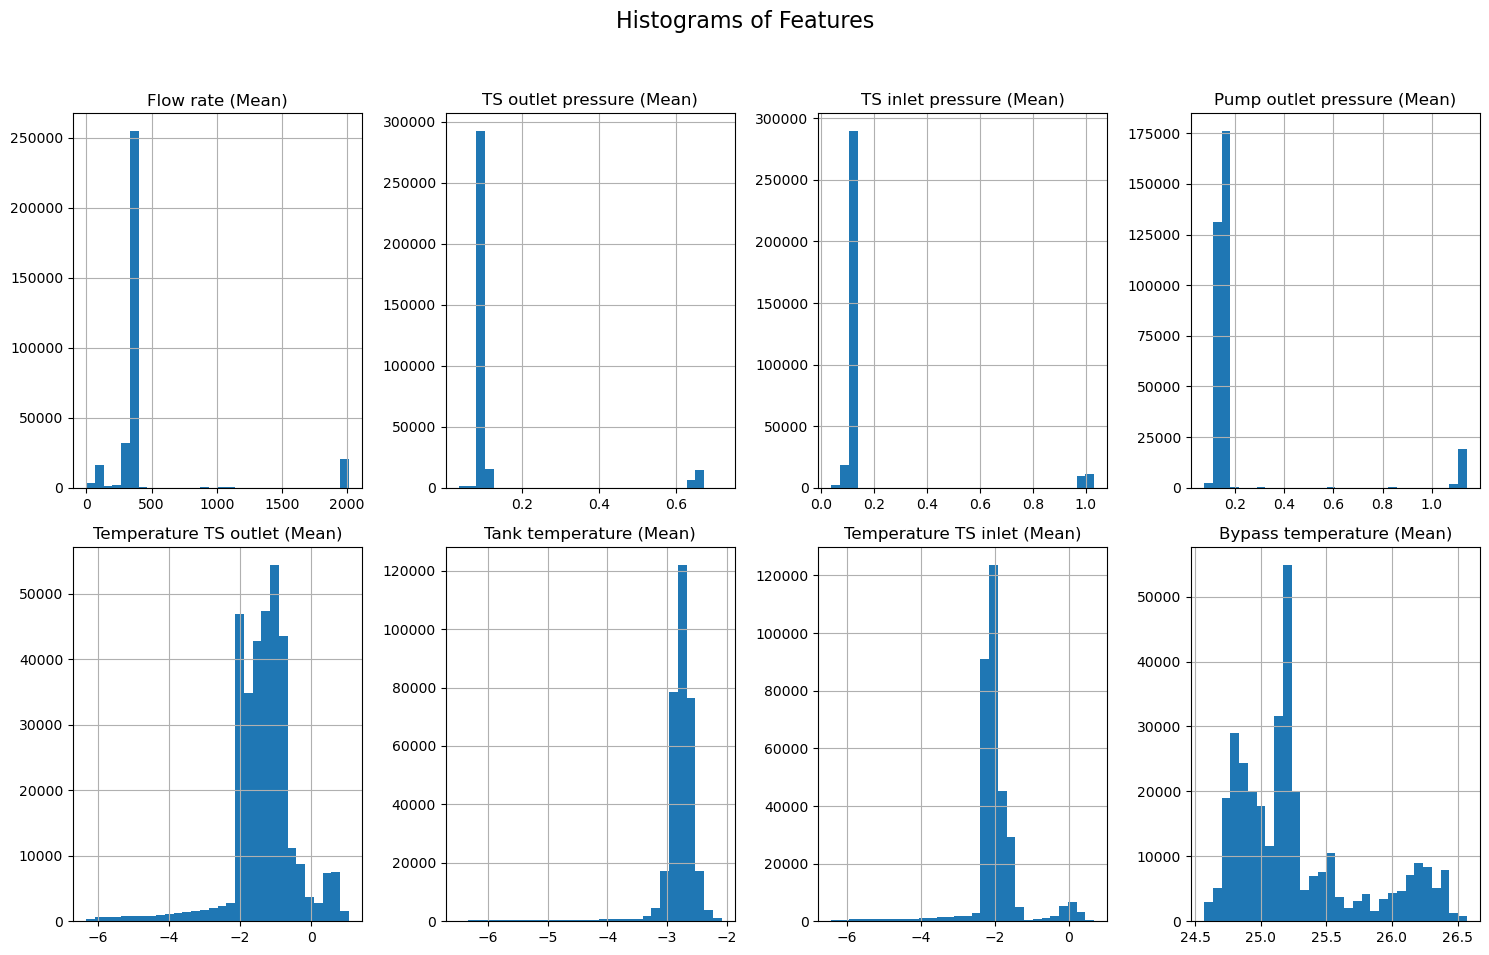

In [12]:
# Histograms for each numeric feature
df_data1.select_dtypes(include=[np.number]).hist(bins=30, figsize=(15, 10), layout=(2, -1))
plt.suptitle('Histograms of Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

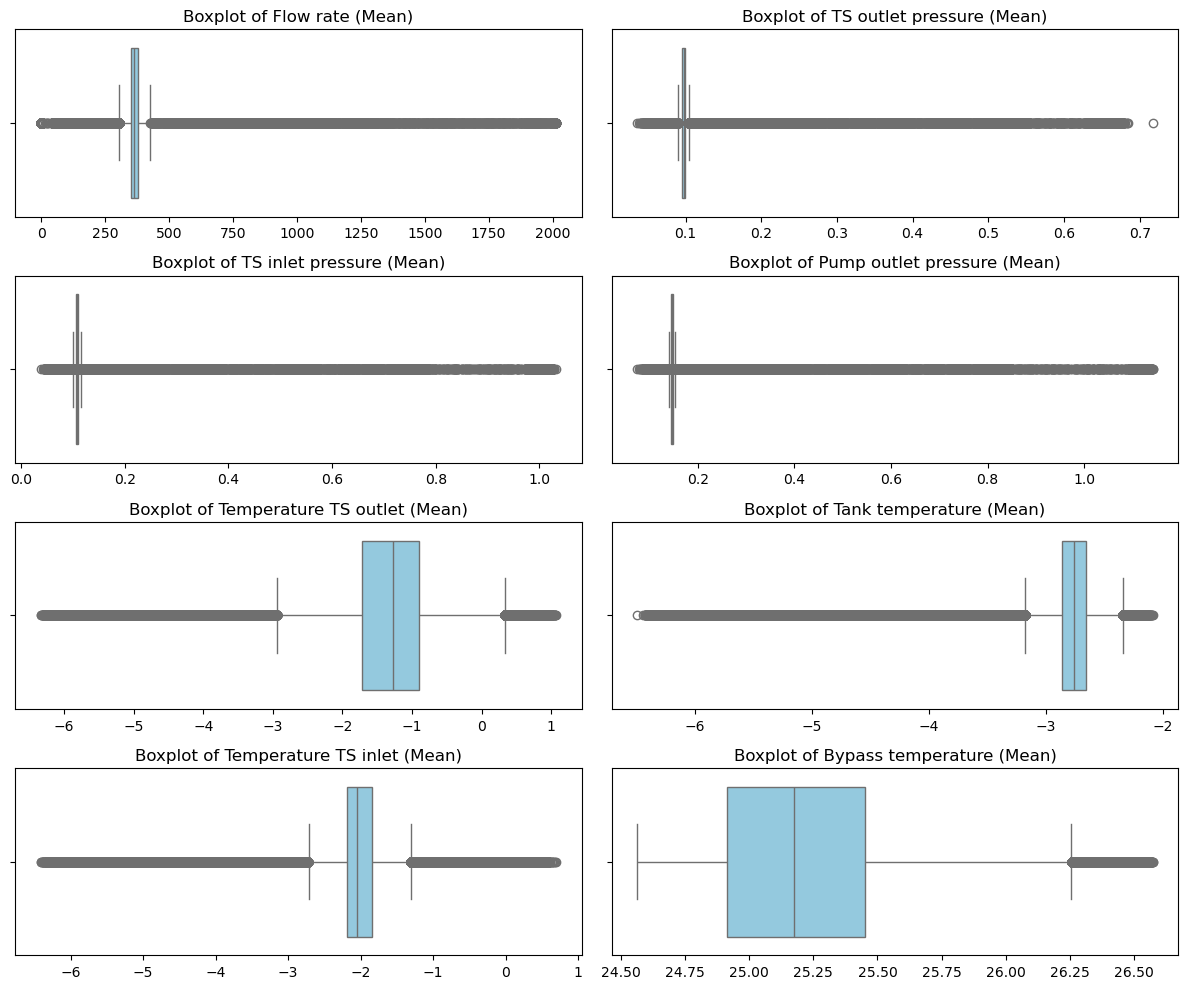

In [13]:
# Boxplots for each numeric feature
df_numeric = df_data1.select_dtypes(include=[np.number])
num_features = df_numeric.shape[1]
cols = 2
rows = (num_features + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
axes = axes.flatten()

for i, col in enumerate(df_numeric.columns):
    sns.boxplot(x=df_numeric[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel("")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [14]:
df_data1.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105


In [15]:
def visualize_flow_rate(data):
    plt.figure(figsize=(12,6))
    plt.plot(data.index, data["Flow rate (Mean)"], label="Flow rate")
    plt.plot(data.index, data["Pump outlet pressure (Mean)"], label="Pump outlet pressure")

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Flow rate & Pump outlet pressure over time")
    plt.legend()
    plt.show()

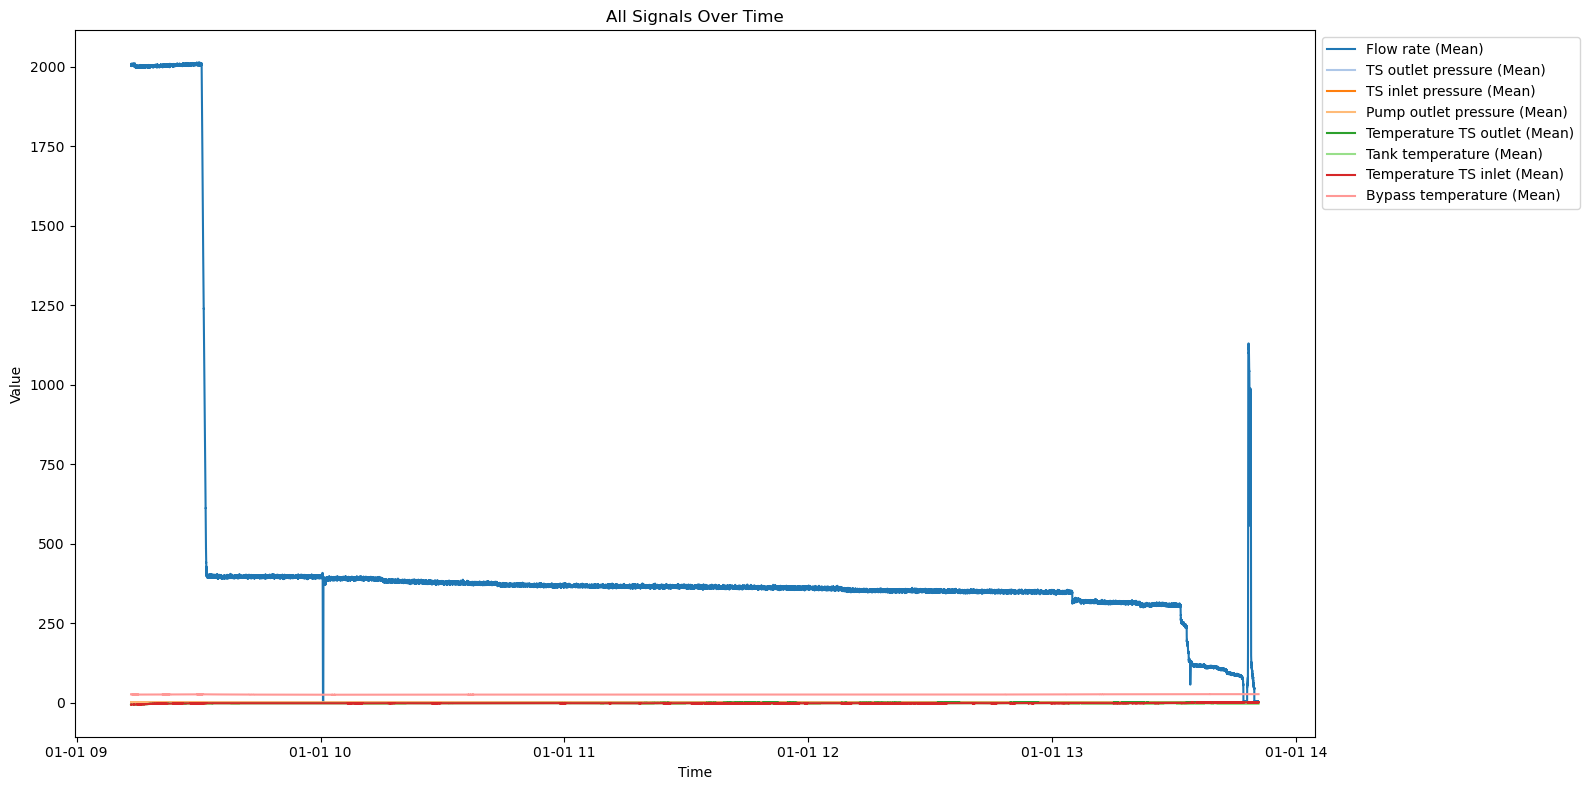

In [16]:
def plot_flow_pressure_drop_temp(data):
    plt.figure(figsize=(16,8))
    colors = plt.cm.tab20.colors  # Use a colormap for up to 20 columns, cycle if more
    for i, col in enumerate(data.columns):
        plt.plot(data.index, data[col], label=col, color=colors[i % len(colors)])
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("All Signals Over Time")
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()

plot_flow_pressure_drop_temp(df_data1)

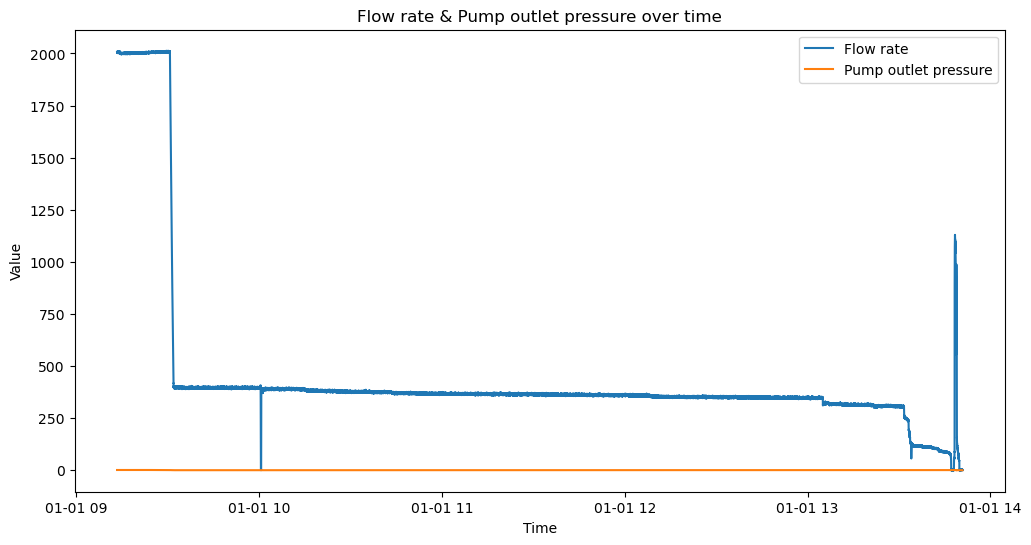

In [17]:
visualize_flow_rate(df_data1)

### Make a target column for the dataframe
This target column is set based on a treshhold (supervised learning).
Another way to do this would be with anomaly detection, (unsupervised learning).

In [18]:
def create_target_column(df):
   # Make the target column based on tresholds
    flow = df["Flow rate (Mean)"]
    pressure = df["Pump outlet pressure (Mean)"]

    # thresholds
    flow_thresh = flow.median() * 0.7
    pressure_thresh = pressure.median() * 1.3

    df["Plug"] = np.where((flow < flow_thresh) & (pressure > pressure_thresh), 1, 0)

In [19]:
create_target_column(df_data1)

In [20]:
df_data1.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug
Time,,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,0
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727,0
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105,0


In [21]:
# find a row with plug value of 1
plug_row = df_data1[df_data1["Plug"] == 1]
plug_row.head(1)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug
Time,,,,,,,,,
1900-01-01 13:47:57.514,0.462633,0.1534,0.152884,0.193321,0.793155,-3.144321,0.371828,26.406,1


In [22]:
def visualize_plug_event(data):
    plt.figure(figsize=(12,6))

    # Plot all data
    plt.plot(data.index, data["Flow rate (Mean)"], label="Flow rate", alpha=0.5)
    plt.plot(data.index, data["Pump outlet pressure (Mean)"], label="Pump outlet pressure", alpha=0.5)

    # Highlight Plug=1 events
    plug_events = data[data["Plug"] == 1]
    plt.scatter(plug_events.index, plug_events["Flow rate (Mean)"], color="red", label="Plug=1 (Flow)", zorder=5)
    plt.scatter(plug_events.index, plug_events["Pump outlet pressure (Mean)"], color="orange", label="Plug=1 (Pressure)", zorder=5)

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Plug=1 Events Highlighted on Flow and Pressure")
    plt.legend()
    plt.show()

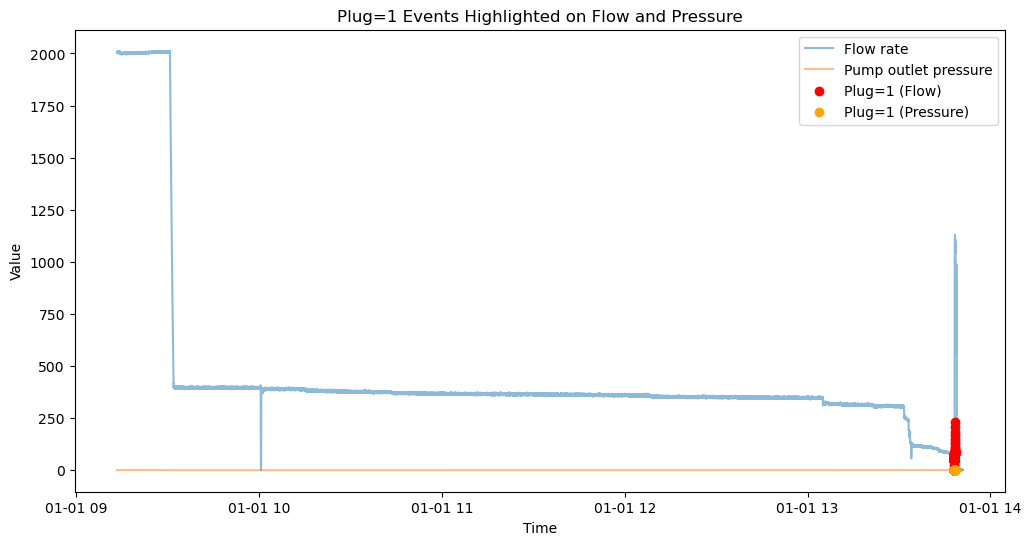

In [23]:
visualize_plug_event(df_data1)

### Split the data into training and test

In [24]:
def train_val_test_split(X,y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.0095, random_state=42, shuffle=False)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=False)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [25]:
def split_data(df):
    X = df.drop(columns=['Plug', 'Plug_future'])
    y = df['Plug_future']

    X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [26]:
# Predict plug event 10 steps ahead
df_data1['Plug_future'] = df_data1['Plug'].shift(-10)
df_data1 = df_data1.dropna(subset=['Plug_future'])

# Chronological split (no shuffle)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_data1)

In [27]:
# Check class balance in each split
print("Train set:")
print(y_train.value_counts())
print("Validation set:")
print(y_val.value_counts())
print("Test set:")
print(y_test.value_counts())

Train set:
Plug_future
0.0    329469
1.0       278
Name: count, dtype: int64
Validation set:
Plug_future
0.0    1531
1.0      50
Name: count, dtype: int64
Test set:
Plug_future
0.0    1582
Name: count, dtype: int64


## Baseline model
Try to train a baseline model on the data.

In [28]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_val_pred = baseline.predict(X_val)
print("Validation set results (baseline):")
print(classification_report(y_val, y_val_pred, digits=3))

Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.968     1.000     0.984      1531
         1.0      0.000     0.000     0.000        50

    accuracy                          0.968      1581
   macro avg      0.484     0.500     0.492      1581
weighted avg      0.938     0.968     0.953      1581



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### RandomForestClassifier

In [29]:
def train_and_evaluate_rf(X_train, X_val, y_train, y_val):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    val_score = model.score(X_val, y_val)
    print(f"Validation accuracy: {val_score:.3f}")
    return model

In [30]:
model = train_and_evaluate_rf(X_train, X_val, y_train, y_val)

Validation accuracy: 0.832


In [31]:
print(X_train.shape)
print(X_train.columns)
print(model.feature_importances_)

(329747, 8)
Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)'],
      dtype='object')
[0.14131598 0.28430301 0.22784184 0.14879016 0.053626   0.01429668
 0.05049438 0.07933196]


### Check feature importance / redundancy
Check which features can be removed due to high correlation, or very low importance.

/var/folders/c8/5vq5y6ts15z8l649rhrn893r0000gn/T/ipykernel_20732/2935910611.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


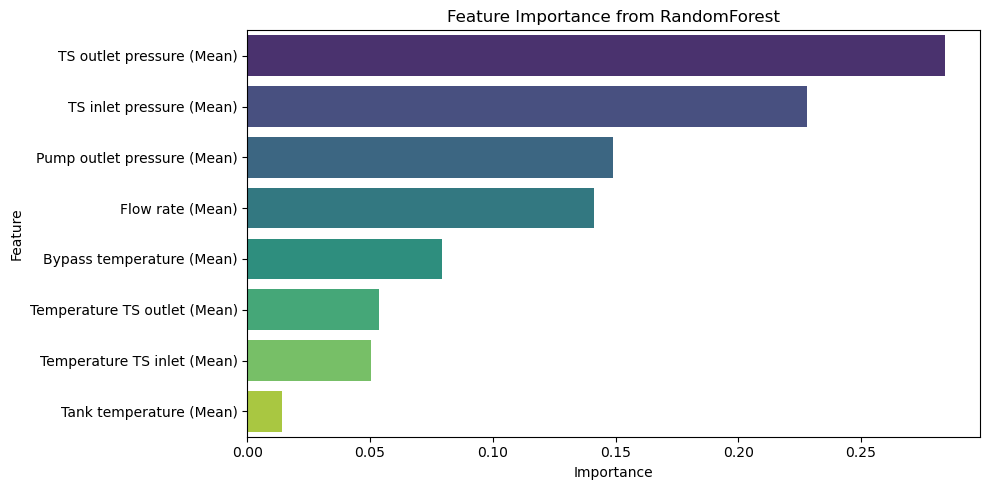

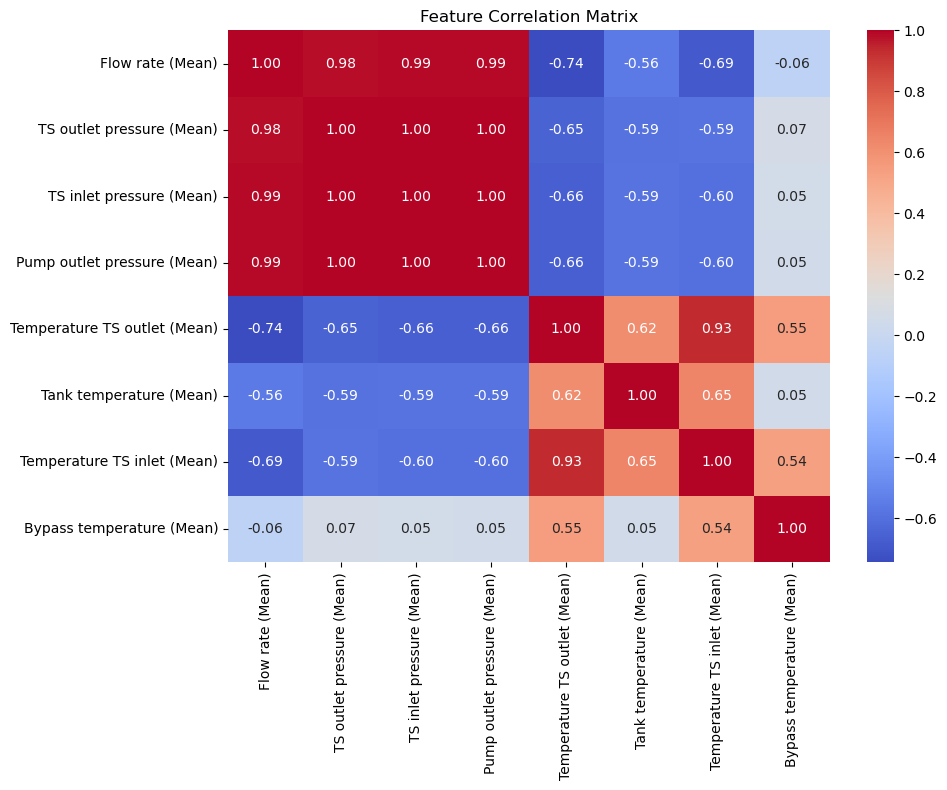

In [32]:
# Feature importance from RandomForest
importances = model.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title('Feature Importance from RandomForest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Correlation matrix to spot redundant features
corr = X_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [33]:
# Remove low-importance features
low_importance = feat_imp[feat_imp < 0.04].index
X_train_reduced = X_train.drop(columns=low_importance)
X_val_reduced = X_val.drop(columns=low_importance)
X_test_reduced = X_test.drop(columns=low_importance)

# Remove one of each pair of highly correlated features
corr_matrix = X_train_reduced.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_reduced = X_train_reduced.drop(columns=to_drop)
X_val_reduced = X_val_reduced.drop(columns=to_drop)
X_test_reduced = X_test_reduced.drop(columns=to_drop)

In [34]:
low_importance

Index(['Tank temperature (Mean)'], dtype='object')

In [35]:
X_train_reduced

,Flow rate (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean)
Time,,,
1900-01-01 09:13:23.564,2006.990755,-6.231957,25.589479
1900-01-01 09:13:23.614,2006.802163,-6.287087,25.573727
1900-01-01 09:13:23.664,2006.990755,-6.245083,25.592105
1900-01-01 09:13:23.714,2005.764905,-6.255584,25.584228
1900-01-01 09:13:23.764,2005.576313,-6.247708,25.589479
...,...,...,...
1900-01-01 13:48:10.664,66.281357,0.588387,26.424378
1900-01-01 13:48:10.714,67.130023,0.512255,26.432254
1900-01-01 13:48:10.764,67.884392,0.596263,26.408625


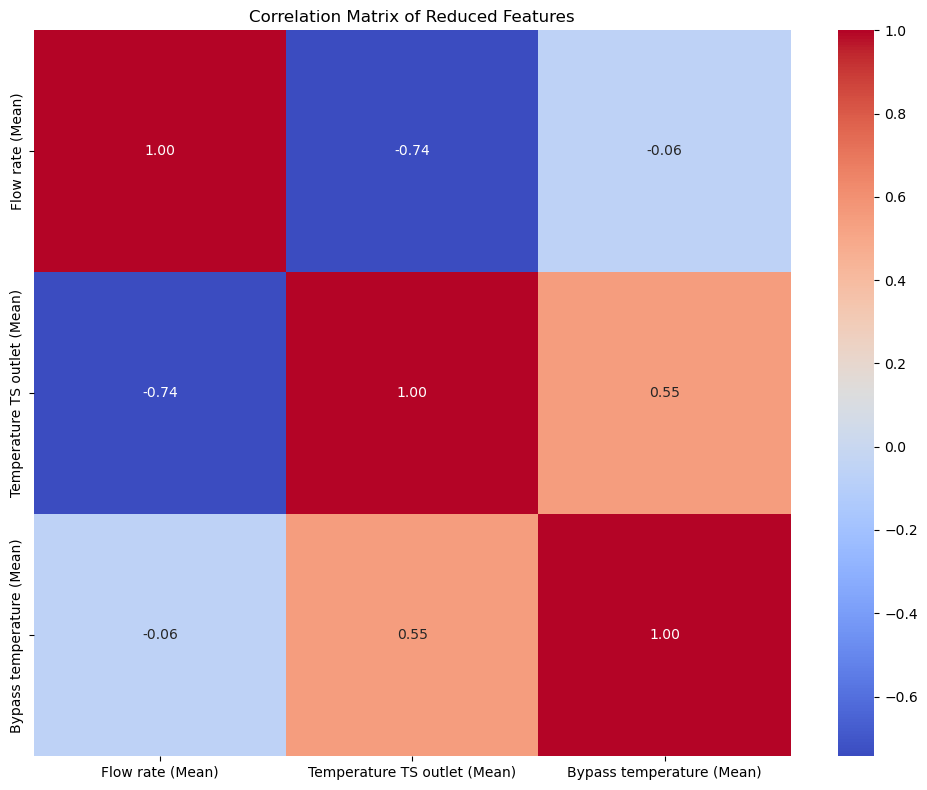

In [36]:
# Correlation matrix of X_train_reduced
corr_reduced = X_train_reduced.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_reduced, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title('Correlation Matrix of Reduced Features')
plt.tight_layout()
plt.show()

In [37]:
model_reduced = train_and_evaluate_rf(X_train_reduced, X_val_reduced, y_train, y_val)

Validation accuracy: 0.968


In [38]:
# Resample only the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print('After SMOTE:', y_train_resampled.value_counts())
print('After SMOTE (%):', y_train_resampled.value_counts(normalize=True))


# Train model on resampled data
model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation and test sets
y_val_pred = model.predict(X_val)
print('Validation set results:')
print(classification_report(y_val, y_val_pred, digits=3))

After SMOTE: Plug_future
0.0    329469
1.0    329469
Name: count, dtype: int64
After SMOTE (%): Plug_future
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64
Validation set results:
              precision    recall  f1-score   support

         0.0      0.996     0.886     0.938      1531
         1.0      0.205     0.900     0.333        50

    accuracy                          0.886      1581
   macro avg      0.600     0.893     0.636      1581
weighted avg      0.971     0.886     0.919      1581



In [39]:
# Check class balance for the target variable
print(df_data1["Plug"].value_counts())
print(df_data1["Plug"].value_counts(normalize=True))

Plug
0    332582
1       328
Name: count, dtype: int64
Plug
0    0.999015
1    0.000985
Name: proportion, dtype: float64


In [40]:
# Shift the Plug column by -10 rows (if sampled every second)
df_data1['Plug_future'] = df_data1['Plug'].shift(-10)

# Drop rows with missing future target
df_data1 = df_data1.dropna(subset=['Plug_future'])

In [41]:
def split_data(df):
    X = df.drop(columns=['Plug', 'Plug_future'])
    y = df['Plug_future']

    X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [42]:
def scale_features(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_val_scaled, X_test_scaled

In [43]:
def logistic_regression_model(X_train_scaled, y_train, X_val_scaled, y_val):
    # Train the model
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    logreg.fit(X_train_scaled, y_train)

    # Evaluate the model
    val_pred = logreg.predict(X_val_scaled)
    print('Validation set results for logistic regression:')
    print(classification_report(y_val, val_pred, digits=3))
    return logreg

In [44]:
X_train_scaled, X_val_scaled, X_test_scaled = scale_features(X_train, X_val, X_test)

logreg = logistic_regression_model(X_train_scaled, y_train, X_val_scaled, y_val)

Validation set results for logistic regression:
              precision    recall  f1-score   support

         0.0      1.000     0.686     0.814      1531
         1.0      0.094     1.000     0.172        50

    accuracy                          0.696      1581
   macro avg      0.547     0.843     0.493      1581
weighted avg      0.971     0.696     0.793      1581



# Dataset 2

In [45]:
df_data2 = load_data("../data/raw_data/data2/*.csv")
print(df_data2.shape)
df_data2.columns

(2046277, 8)


Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)'],
      dtype='object')

In [46]:
df_data2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2046277 entries, 1900-01-01 13:21:20.972000 to 1900-01-01 19:02:23.732000
Data columns (total 8 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Flow rate (Mean)              float64
 1   TS outlet pressure (Mean)     float64
 2   TS inlet pressure (Mean)      float64
 3   Pump outlet pressure (Mean)   float64
 4   Temperature TS outlet (Mean)  float64
 5   Tank temperature (Mean)       float64
 6   Temperature TS inlet (Mean)   float64
 7   Bypass temperature (Mean)     float64
dtypes: float64(8)
memory usage: 140.5 MB


In [47]:
df_data2.describe(include="all")

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
count,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06
mean,4.277005e+02,1.237998e-01,1.453959e-01,1.922374e-01,-4.462725e-01,-2.632296e+00,-6.490695e-01,2.461759e+01
std,2.364495e+02,7.511268e-02,1.200806e-01,1.299952e-01,5.067265e-01,1.980324e-01,5.661325e-01,4.406262e-01
min,3.669918e+02,9.627600e-02,1.088850e-01,1.536320e-01,-4.032015e+00,-4.514561e+00,-4.382203e+00,2.376215e+01
25%,3.820792e+02,1.083520e-01,1.220110e-01,1.683310e-01,-6.585970e-01,-2.742699e+00,-9.433400e-01,2.411659e+01
50%,3.853796e+02,1.109770e-01,1.251610e-01,1.701690e-01,-3.698210e-01,-2.624575e+00,-5.495770e-01,2.486485e+01
75%,3.948092e+02,1.141280e-01,1.283120e-01,1.729250e-01,-1.598030e-01,-2.506451e+00,-2.739430e-01,2.500925e+01
max,1.876673e+03,6.139630e-01,9.132490e-01,1.072359e+00,5.621350e-01,-1.942080e+00,7.629660e-01,2.528493e+01


In [48]:
df_data2.isnull().sum()

Flow rate (Mean)                0
TS outlet pressure (Mean)       0
TS inlet pressure (Mean)        0
Pump outlet pressure (Mean)     0
Temperature TS outlet (Mean)    0
Tank temperature (Mean)         0
Temperature TS inlet (Mean)     0
Bypass temperature (Mean)       0
dtype: int64

In [49]:
df_data2.duplicated().sum()

np.int64(21)

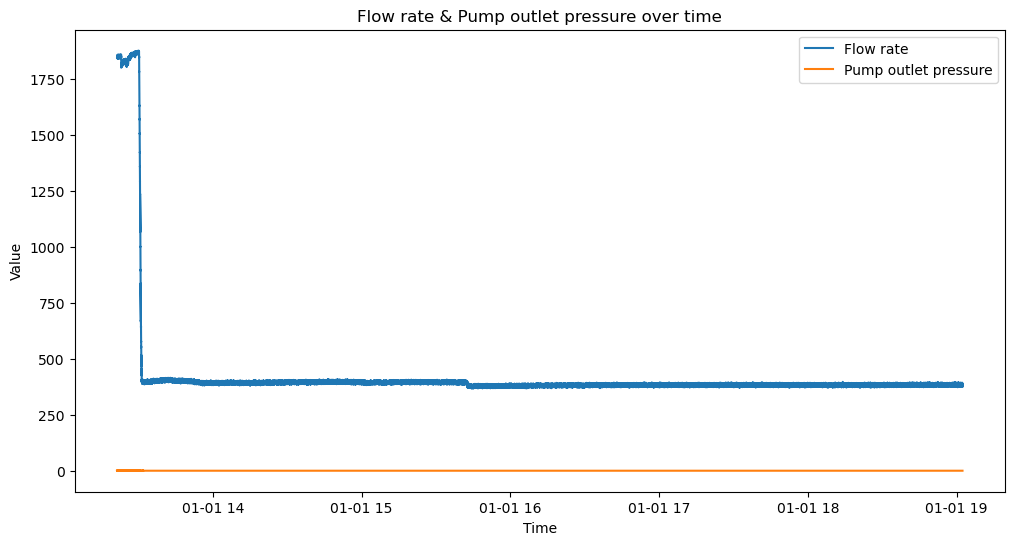

In [50]:
visualize_flow_rate(df_data2)

In [51]:
create_target_column(df_data2)

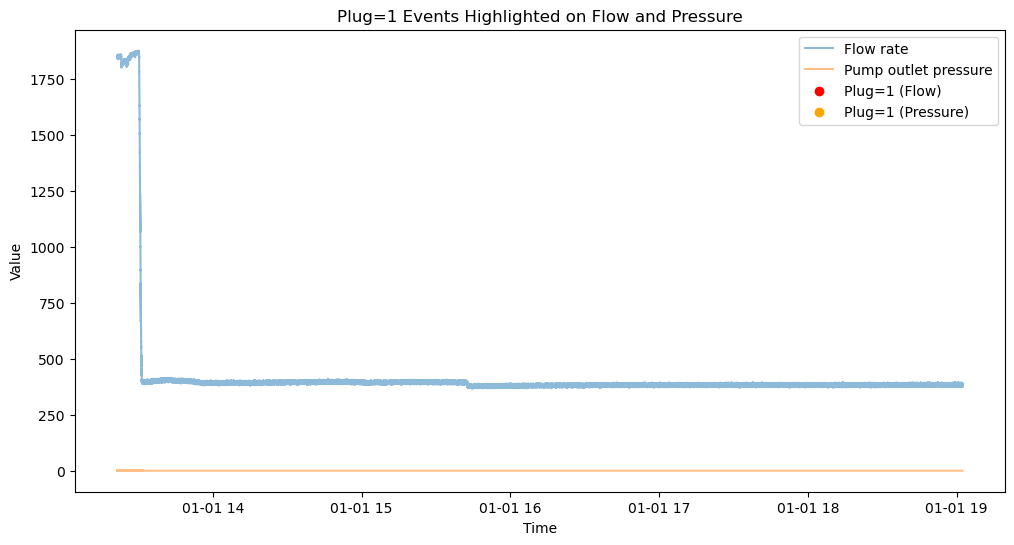

In [52]:
visualize_plug_event(df_data2)

In [53]:
# Predict plug event 10 steps ahead
df_data2['Plug_future'] = df_data2['Plug'].shift(-10)
df_data2 = df_data2.dropna(subset=['Plug_future'])

In [54]:
X_train2, X_val2, X_test2, y_train2, y_val2, y_test2 = split_data(df_data2)
model2 = train_and_evaluate_rf(X_train2, X_val2, y_train2, y_val2)

Validation accuracy: 1.000


In [55]:
X_train_scaled2, X_val_scaled2, X_test_scaled2= scale_features(X_train2, X_val2, X_test2)

logreg = logistic_regression_model(X_train_scaled2, y_train2, X_val_scaled2, y_val2)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.float64(0.0)